# BAMv3 실험: 노이즈→노이즈 학습

**Ultra-low SNR 환경을 위한 Robust Feature Learning**
- Self-supervised 학습 방식
- 다양한 SNR에서 일관된 패턴 학습
- 병목 효과로 랜덤 노이즈 제거


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.LoRa import LoRa, MultiBAMv3
import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

print(utils.my_lora_utils.__file__)


/home/gwon9906/LoRa-bam-reconstruction/utils/my_lora_utils.py


In [2]:
########################################
##  Complex 스펙트로그램 생성 함수     ##
########################################

from scipy.signal import spectrogram, istft

def generate_complex_spectrogram(iq_signal, fs, bw=250_000, nperseg=192, noverlap=144, nfft=512):
    """
    복소 IQ 신호로부터 Complex 스펙트로그램 생성 (Phase 정보 보존)
    
    Parameters:
    -----------
    iq_signal : complex array
        복소 IQ 신호
    fs : float
        샘플링 주파수
    bw : float
        대역폭 (크롭용, default: 250_000)
    nperseg : int
        각 세그먼트의 길이 (default: 128)
    noverlap : int
        세그먼트 간 오버랩 (default: 64)
    nfft : int
        FFT 크기 (default: 512)
    
    Returns:
    --------
    combined_flat : ndarray
        Real과 Imag를 통합한 1D 배열 (크롭된 주파수 × 시간 × 2)
    spec_shape : tuple
        원본 스펙트로그램 shape (주파수, 시간)
    norm_params : dict
        역정규화를 위한 파라미터 (min, max)
    """
    # Complex 스펙트로그램 계산 (Phase 보존!)
    f, t, Zxx = spectrogram(
        iq_signal, 
        fs=fs, 
        window='hann',
        nperseg=nperseg, 
        noverlap=noverlap,
        nfft=nfft, 
        mode='complex',  # ← 핵심: Complex mode
        return_onesided=False
    )
    
    # 주파수 축 시프트 (DC를 중앙으로)
    f = np.fft.fftshift(f)
    Zxx = np.fft.fftshift(Zxx, axes=0)
    
    # 대역폭만큼 크롭
    mask = (f >= -bw/2) & (f < bw/2)
    Zxx_cropped = Zxx[mask, :]
    
    # Real/Imag 분리
    real_part = Zxx_cropped.real
    imag_part = Zxx_cropped.imag
    
    # 개별 정규화 (0-1 범위)
    r_min, r_max = real_part.min(), real_part.max()
    i_min, i_max = imag_part.min(), imag_part.max()
    
    real_norm = (real_part - r_min) / (r_max - r_min + 1e-12)
    imag_norm = (imag_part - i_min) / (i_max - i_min + 1e-12)
    
    # Real/Imag 통합 (Flatten)
    real_flat = real_norm.flatten()
    imag_flat = imag_norm.flatten()
    combined_flat = np.concatenate([real_flat, imag_flat])
    
    # 역변환을 위한 정보 저장
    norm_params = {
        'r_min': r_min, 'r_max': r_max,
        'i_min': i_min, 'i_max': i_max,
        'shape': Zxx_cropped.shape
    }
    
    return combined_flat, norm_params

print("✅ Complex 스펙트로그램 함수가 정의되었습니다 (Phase 보존)")


✅ Complex 스펙트로그램 함수가 정의되었습니다 (Phase 보존)


In [3]:
# LoRa 파라미터 설정
sf = 9
bw = 250_000  # 250 kHz
OSF = 4
fs = int(bw * OSF)  # 1 MHz

print(f"SF = {sf}, BW = {bw/1e3:.1f} kHz, fs = {fs/1e6:.3f} MHz")

# LoRa 인스턴스 생성 (on-the-fly 노이즈 추가용)
lora = LoRa(sf, bw)


SF = 9, BW = 250.0 kHz, fs = 1.000 MHz


In [4]:
########################################
##  1. 클린 IQ 데이터 로드            ##
########################################

base_dir = "dataset_v3_sf9_bw250k"
iq_dir = os.path.join(base_dir, "clean_iq")

print("Loading clean IQ data...")
iq_files = sorted(glob.glob(os.path.join(iq_dir, "*.npy")))
print(f"Found {len(iq_files)} clean IQ files")

# 클린 IQ 로드
iq_data_list = []
for f in iq_files:
    x_clean = np.load(f)  # complex IQ
    iq_data_list.append(x_clean)

X_clean_iq = np.array(iq_data_list)
print(f"Clean IQ shape: {X_clean_iq.shape}, dtype: {X_clean_iq.dtype}")


Loading clean IQ data...
Found 512 clean IQ files
Clean IQ shape: (512, 2048), dtype: complex64


In [5]:
########################################
##  2. 데이터 증강 함수 정의          ##
########################################

# SNR 범위 설정 (Ultra-low SNR에 집중)
SNR_MIN = -25
SNR_MAX = -5
AUGMENT_FACTOR = 30  # 각 클린 IQ를 30배로 증강

def augment_dataset(X_clean_iq, augment_factor=30):
    """
    클린 IQ를 N배로 증강 (매번 다른 랜덤 노이즈 추가)
    Complex 스펙트로그램 사용 (Phase 정보 보존)
    
    Returns:
        X_noisy_flat: (512*augment_factor, input_dim) 형태
        norm_params_list: 각 샘플의 역정규화 파라미터
    """
    print(f"\nGenerating {len(X_clean_iq)} × {augment_factor} = {len(X_clean_iq) * augment_factor} augmented samples...")
    
    X_noisy_flat_list = []
    norm_params_list = []
    
    for clean_iq in X_clean_iq:
        for _ in range(augment_factor):
            # 랜덤 SNR 선택
            snr = np.random.randint(SNR_MIN, SNR_MAX + 1)
            
            # 노이즈 추가
            noisy_iq = lora.awgn_iq(clean_iq, snr)
            
            # Complex 스펙트로그램 생성 (Phase 보존)
            spec_flat, norm_params = generate_complex_spectrogram(noisy_iq, fs, bw)
            X_noisy_flat_list.append(spec_flat)
            norm_params_list.append(norm_params)
    
    X_noisy_flat = np.array(X_noisy_flat_list)
    
    print(f"Augmented dataset shape: {X_noisy_flat.shape}")
    print(f"  - Real/Imag combined (Phase preserved)")
    
    return X_noisy_flat, norm_params_list

print(f"✅ Complex augmentation function defined: {AUGMENT_FACTOR}x per clean IQ")


✅ Complex augmentation function defined: 30x per clean IQ


In [6]:
########################################
##  3. 모델 아키텍처 설정             ##
########################################

# Complex 스펙트로그램 shape 확인을 위한 테스트 (1개만)
test_spec_flat, test_params = generate_complex_spectrogram(X_clean_iq[0], fs, bw)
input_dim = test_spec_flat.shape[0]  # Real + Imag 통합 (2배)

# 점진적 압축: 7936 → 4096 → 3072 → 2048
layers = [input_dim, 4096, 3072, 2048]

print(f"Complex spectrogram shape: {test_params['shape']}")
print(f"Input dim (Real+Imag): {input_dim}")
print(f"Model architecture: {' → '.join(map(str, layers))}")
print(f"Compression ratio: {input_dim / layers[-1]:.1f}x")
print(f"Layers: {len(layers)-1} BAM layers (더 부드러운 압축)")


Complex spectrogram shape: (128, 39)
Input dim (Real+Imag): 9984
Model architecture: 9984 → 4096 → 3072 → 2048
Compression ratio: 4.9x
Layers: 3 BAM layers (더 부드러운 압축)


In [7]:
########################################
##  4. BAMv3 Complex 30배 증강 학습  ##
########################################

print(f"\n=== Training BAMv3 Model (Complex Spectrogram) ===")
print(f"Architecture: {' → '.join(map(str, layers))}")
print(f"Strategy: On-the-fly 30x Augmentation per Epoch (Phase Preserved)")

# BAMv3 모델 생성 (학습률 조정: 3-layer BAM에 적합한 lr)
model = MultiBAMv3(layers_dims=layers, eta=5e-4)

# 학습 플래그
TRAIN = False  # 테스트 전에는 False

if TRAIN:
    print("\n=== Starting Training with On-the-fly Complex Augmentation ===")
    print(f"Base samples: {len(X_clean_iq)}")
    print(f"Augmentation factor: {AUGMENT_FACTOR}x")
    print(f"Total per epoch: {len(X_clean_iq) * AUGMENT_FACTOR}")
    
    # 학습 파라미터
    num_epochs = 20
    batch_size = 64
    
    all_layer_losses = [[] for _ in range(len(layers)-1)]
    
    # 매 epoch마다 새로운 노이즈로 증강
    for epoch in range(num_epochs):
        print(f"\n{'='*60}")
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"{'='*60}")
        
        # 30배 증강된 Complex 데이터 생성 (매 epoch마다 다른 노이즈!)
        X_augmented, _ = augment_dataset(X_clean_iq, AUGMENT_FACTOR)
        
        # 1 epoch만 학습 (이미 증강된 데이터로)
        layer_losses = model.train(X_augmented, num_epochs=1, batch_size=batch_size)
        
        # Loss 기록
        for i, losses in enumerate(layer_losses):
            all_layer_losses[i].extend(losses)
    
    print("\n=== Training Complete ===")
    
    # Loss 플롯 (각 layer별)
    fig, axes = plt.subplots(1, len(all_layer_losses), figsize=(15, 4))
    if len(all_layer_losses) == 1:
        axes = [axes]
    
    for i, losses in enumerate(all_layer_losses):
        axes[i].plot(losses)
        axes[i].set_xlabel('Batch')
        axes[i].set_ylabel('MSE Loss')
        axes[i].set_title(f'Layer {i+1} Training Loss (Complex)')
        axes[i].grid(True)
    
    plt.tight_layout()
    plt.show()
else:
    print("\nTraining skipped (TRAIN=False)")



=== Training BAMv3 Model (Complex Spectrogram) ===
Architecture: 9984 → 4096 → 3072 → 2048
Strategy: On-the-fly 30x Augmentation per Epoch (Phase Preserved)

Training skipped (TRAIN=False)


In [8]:
########################################
##  5. 모델 저장                     ##
########################################

import torch

if TRAIN:
    # 모델 저장 폴더
    weight_folder = "weights_bamv3_complex"
    os.makedirs(weight_folder, exist_ok=True)
    
    # 각 layer의 weight 저장
    for i, bam in enumerate(model.bams):
        weight_path = os.path.join(weight_folder, f"weights_layer_{i}.npy")
        np.save(weight_path, bam.W.cpu().numpy())
        print(f"✅ Layer {i} weights saved to: {weight_path}")
    
    # 아키텍처 정보 저장
    config = {
        'layers': layers,
        'eta': 5e-4,
        'sf': sf,
        'bw': bw,
        'fs': fs,
        'mode': 'complex'  # Complex 방식 표시
    }
    config_path = os.path.join(weight_folder, "model_config.npy")
    np.save(config_path, config)
    print(f"✅ Config saved to: {config_path}")

print("\n=== How to Load Model ===")
print("""
# 모델 로드 예시:
config = np.load('weights_bamv3_complex/model_config.npy', allow_pickle=True).item()
model = MultiBAMv3(layers_dims=config['layers'], eta=config['eta'])
for i, bam in enumerate(model.bams):
    bam.W = torch.tensor(np.load(f'weights_bamv3_complex/weights_layer_{i}.npy'))
""")



=== How to Load Model ===

# 모델 로드 예시:
config = np.load('weights_bamv3_complex/model_config.npy', allow_pickle=True).item()
model = MultiBAMv3(layers_dims=config['layers'], eta=config['eta'])
for i, bam in enumerate(model.bams):
    bam.W = torch.tensor(np.load(f'weights_bamv3_complex/weights_layer_{i}.npy'))



In [9]:
########################################
##  5-1. 학습된 모델 로드 (TRAIN=False일 때)  ##
########################################

import torch

# TRAIN=False인 경우에만 저장된 모델 로드
if not TRAIN:
    weight_folder = "weights_bamv3_complex"
    
    # Config 파일이 존재하는지 확인
    config_path = os.path.join(weight_folder, "model_config.npy")
    
    if os.path.exists(config_path):
        print(f"\n=== Loading Pre-trained Model ===")
        
        # Config 로드
        config = np.load(config_path, allow_pickle=True).item()
        print(f"Loaded config: {config}")
        
        # 아키텍처가 동일한지 확인
        if config['layers'] == layers:
            # 각 layer의 weight 로드
            for i, bam in enumerate(model.bams):
                weight_path = os.path.join(weight_folder, f"weights_layer_{i}.npy")
                if os.path.exists(weight_path):
                    loaded_weight = np.load(weight_path)
                    # 🔧 디바이스 지정 추가! (CPU/CUDA 자동 감지)
                    bam.W = torch.tensor(loaded_weight, dtype=torch.float32).to(bam.device)
                    print(f"✅ Layer {i} weights loaded from: {weight_path} (device: {bam.device})")
                else:
                    print(f"❌ Warning: {weight_path} not found!")
            
            print(f"✅ Model successfully loaded from {weight_folder}")
        else:
            print(f"❌ Warning: Architecture mismatch!")
            print(f"   Current: {layers}")
            print(f"   Saved:   {config['layers']}")
    else:
        print(f"❌ Warning: No pre-trained model found in {weight_folder}")
        print(f"   Please set TRAIN=True to train a new model first.")
else:
    print("\n=== Using Newly Trained Model ===")
    print("Model weights from training will be used.")



=== Loading Pre-trained Model ===
Loaded config: {'layers': [7936, 4096, 3072, 2048], 'eta': 0.0005, 'sf': 9, 'bw': 250000, 'fs': 1000000, 'mode': 'complex'}
❌ Warning: Architecture mismatch!
   Current: [9984, 4096, 3072, 2048]
   Saved:   [7936, 4096, 3072, 2048]



=== Testing Complex Reconstruction ===
Test symbol: 42, SNR: -10 dB

=== Normalization Parameters ===
Real: min=-0.011800, max=0.014469, range=0.026269
Imag: min=-0.011897, max=0.014710, range=0.026606
Restored norm: real_min=-0.0050, real_max=0.0056
Restored norm: imag_min=-0.0043, imag_max=0.0061
After denorm:  real_min=-0.011931, real_max=-0.011653
After denorm:  imag_min=-0.012012, imag_max=-0.011733
✅ IQ signal reconstructed (before resampling): (2432,)
   🔧 Resampled: 2432 → 2048 samples (Sinc interpolation)
   Energy before scaling: |mean|=0.006010, |max|=0.014185
   Energy scaling: 3.256377 / 0.006996 = 465.47x
   Energy after scaling:  |mean|=2.797560, |max|=6.602749

=== Debug: Values Check ===
Noisy flat:    min=0.0000, max=1.0000, mean=0.4481
Restored flat: min=-0.0050, max=0.0061, mean=0.0004
Difference:    MSE=0.209507


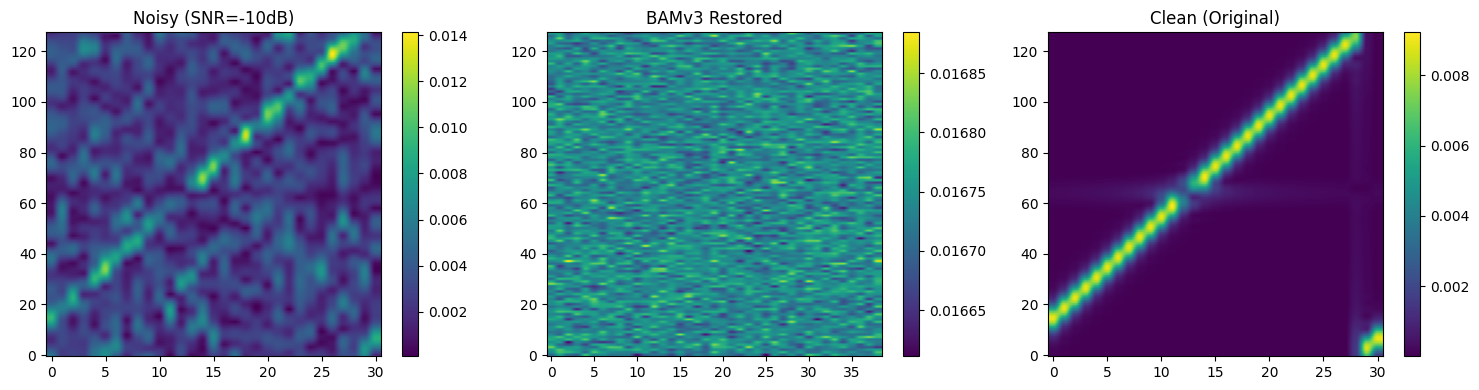


=== Spectrogram Magnitude Check ===
Zxx_noisy (magnitude):    min=0.0001, max=0.0141
Zxx_restored (magnitude): min=0.0166, max=0.0169
Zxx_clean (magnitude):    min=0.0000, max=0.0092


In [10]:
########################################
##  6. 테스트: Complex 복원 및 IQ 재구성  ##
########################################

# 테스트 샘플 선택
test_symbol = 42  # 테스트할 심볼 (0~511)
test_snr = -10    # 테스트 SNR

print(f"\n=== Testing Complex Reconstruction ===")
print(f"Test symbol: {test_symbol}, SNR: {test_snr} dB")

# 1. 클린 IQ 생성
clean_iq = X_clean_iq[test_symbol]

# 2. 노이즈 추가
noisy_iq = lora.awgn_iq(clean_iq, test_snr)

# 3. Complex 스펙트로그램 생성
noisy_flat, norm_params = generate_complex_spectrogram(noisy_iq, fs, bw)

# 4. BAM 압축/복원
compressed = model.compress(noisy_flat.reshape(1, -1))
restored_flat = model.decompress(compressed).flatten()

# 5. Real/Imag 분리 및 역정규화 (학습 시와 동일한 스케일 사용)
mid = len(restored_flat) // 2
real_restored_norm = restored_flat[:mid].reshape(norm_params['shape'])
imag_restored_norm = restored_flat[mid:].reshape(norm_params['shape'])

# 🔍 정규화 파라미터 확인
print(f"\n=== Normalization Parameters ===")
print(f"Real: min={norm_params['r_min']:.6f}, max={norm_params['r_max']:.6f}, range={norm_params['r_max']-norm_params['r_min']:.6f}")
print(f"Imag: min={norm_params['i_min']:.6f}, max={norm_params['i_max']:.6f}, range={norm_params['i_max']-norm_params['i_min']:.6f}")
print(f"Restored norm: real_min={real_restored_norm.min():.4f}, real_max={real_restored_norm.max():.4f}")
print(f"Restored norm: imag_min={imag_restored_norm.min():.4f}, imag_max={imag_restored_norm.max():.4f}")

# 역정규화 (Noisy 범위 사용 - 학습 시와 일관성 유지)
real_restored = real_restored_norm * (norm_params['r_max'] - norm_params['r_min']) + norm_params['r_min']
imag_restored = imag_restored_norm * (norm_params['i_max'] - norm_params['i_min']) + norm_params['i_min']

print(f"After denorm:  real_min={real_restored.min():.6f}, real_max={real_restored.max():.6f}")
print(f"After denorm:  imag_min={imag_restored.min():.6f}, imag_max={imag_restored.max():.6f}")

# 6. Complex 재결합
Zxx_restored = real_restored + 1j * imag_restored

# 7. 역 STFT로 IQ 신호 복원
Zxx_unshifted = np.fft.ifftshift(Zxx_restored, axes=0)
_, iq_reconstructed = istft(
    Zxx_unshifted, 
    fs=fs, 
    window='hann',
    nperseg=128, 
    noverlap=64,
    nfft=512, 
    input_onesided=False
)

print(f"✅ IQ signal reconstructed (before resampling): {iq_reconstructed.shape}")

# 🔧 길이 보정: Resample (Zero-padding 대신!)
from scipy.signal import resample
target_len = len(clean_iq)  # 원본 LoRa symbol 길이 (2048)
if len(iq_reconstructed) != target_len:
    original_len = len(iq_reconstructed)
    iq_reconstructed = resample(iq_reconstructed, target_len)
    print(f"   🔧 Resampled: {original_len} → {target_len} samples (Sinc interpolation)")
else:
    print(f"   ✅ Length already matches: {target_len} samples")

print(f"   Energy before scaling: |mean|={np.abs(iq_reconstructed).mean():.6f}, |max|={np.abs(iq_reconstructed).max():.6f}")

# 8. 에너지 정규화 (Energy Normalization) ⭐
# iSTFT 후 신호 에너지가 손실되므로, 원본 noisy IQ의 에너지에 맞춰 복원
energy_noisy = np.sqrt(np.mean(np.abs(noisy_iq)**2))
energy_reconstructed = np.sqrt(np.mean(np.abs(iq_reconstructed)**2))

if energy_reconstructed > 1e-10:  # 0으로 나누기 방지
    scale_factor = energy_noisy / energy_reconstructed
    iq_reconstructed = iq_reconstructed * scale_factor
    print(f"   Energy scaling: {energy_noisy:.6f} / {energy_reconstructed:.6f} = {scale_factor:.2f}x")
    print(f"   Energy after scaling:  |mean|={np.abs(iq_reconstructed).mean():.6f}, |max|={np.abs(iq_reconstructed).max():.6f}")
else:
    print(f"   ⚠️  Warning: Reconstructed signal energy too low, no scaling applied")

# 🔍 디버깅: 값 확인
print(f"\n=== Debug: Values Check ===")
print(f"Noisy flat:    min={noisy_flat.min():.4f}, max={noisy_flat.max():.4f}, mean={noisy_flat.mean():.4f}")
print(f"Restored flat: min={restored_flat.min():.4f}, max={restored_flat.max():.4f}, mean={restored_flat.mean():.4f}")
mse_diff = ((noisy_flat - restored_flat)**2).mean()
print(f"Difference:    MSE={mse_diff:.6f}")

# 시각화: Magnitude 스펙트로그램 비교 (모두 같은 파라미터 + BW 크롭)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Noisy 스펙트로그램 (BW 크롭 적용)
f_n, t_n, Zxx_noisy_full = spectrogram(noisy_iq, fs, window='hann', nperseg=128, noverlap=64, nfft=512, mode='complex', return_onesided=False)
f_n = np.fft.fftshift(f_n)
Zxx_noisy_full = np.fft.fftshift(Zxx_noisy_full, axes=0)
mask_n = (f_n >= -bw/2) & (f_n < bw/2)
Zxx_noisy = Zxx_noisy_full[mask_n, :]
im1 = axes[0].imshow(np.abs(Zxx_noisy), aspect='auto', cmap='viridis', origin='lower')
axes[0].set_title(f'Noisy (SNR={test_snr}dB)')
plt.colorbar(im1, ax=axes[0])

# Restored 스펙트로그램 (이미 크롭됨)
im2 = axes[1].imshow(np.abs(Zxx_restored), aspect='auto', cmap='viridis', origin='lower')
axes[1].set_title('BAMv3 Restored')
plt.colorbar(im2, ax=axes[1])

# Clean 스펙트로그램 (BW 크롭 적용)
f_c, t_c, Zxx_clean_full = spectrogram(clean_iq, fs, window='hann', nperseg=128, noverlap=64, nfft=512, mode='complex', return_onesided=False)
f_c = np.fft.fftshift(f_c)
Zxx_clean_full = np.fft.fftshift(Zxx_clean_full, axes=0)
mask_c = (f_c >= -bw/2) & (f_c < bw/2)
Zxx_clean = Zxx_clean_full[mask_c, :]
im3 = axes[2].imshow(np.abs(Zxx_clean), aspect='auto', cmap='viridis', origin='lower')
axes[2].set_title('Clean (Original)')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

# 🔍 스펙트로그램 magnitude 확인
print(f"\n=== Spectrogram Magnitude Check ===")
print(f"Zxx_noisy (magnitude):    min={np.abs(Zxx_noisy).min():.4f}, max={np.abs(Zxx_noisy).max():.4f}")
print(f"Zxx_restored (magnitude): min={np.abs(Zxx_restored).min():.4f}, max={np.abs(Zxx_restored).max():.4f}")
print(f"Zxx_clean (magnitude):    min={np.abs(Zxx_clean).min():.4f}, max={np.abs(Zxx_clean).max():.4f}")


In [11]:
########################################
##  7. Dechirp 및 Code 복원 평가     ##
########################################

from utils.my_lora_utils import estimate_symbol_custom

print("\n=== Dechirp Code Reconstruction Test ===")

# 🔍 IQ 신호 차이 분석
print(f"\n=== IQ Signal Analysis ===")
print(f"Clean IQ:        len={len(clean_iq)}, |mean|={np.abs(clean_iq).mean():.4f}, |max|={np.abs(clean_iq).max():.4f}")
print(f"Noisy IQ:        len={len(noisy_iq)}, |mean|={np.abs(noisy_iq).mean():.4f}, |max|={np.abs(noisy_iq).max():.4f}")
print(f"Reconstructed:   len={len(iq_reconstructed)}, |mean|={np.abs(iq_reconstructed).mean():.4f}, |max|={np.abs(iq_reconstructed).max():.4f}")

# MSE 비교 (길이 맞춤)
min_len = min(len(clean_iq), len(noisy_iq), len(iq_reconstructed))
mse_clean_noisy = np.mean(np.abs(clean_iq[:min_len] - noisy_iq[:min_len])**2)
mse_clean_recon = np.mean(np.abs(clean_iq[:min_len] - iq_reconstructed[:min_len])**2)
mse_noisy_recon = np.mean(np.abs(noisy_iq[:min_len] - iq_reconstructed[:min_len])**2)

print(f"\nMSE Comparison:")
print(f"Clean vs Noisy:        {mse_clean_noisy:.6f}")
print(f"Clean vs Reconstructed: {mse_clean_recon:.6f}")
print(f"Noisy vs Reconstructed: {mse_noisy_recon:.6f}")

# Dechirp 및 심볼 복원 테스트
print(f"\n=== Dechirp Symbol Decoding ===")

# 1. 원본 클린 신호 Dechirp
code_clean, peak_clean = estimate_symbol_custom(clean_iq, "clean", sf, fs, bw)
print(f"✅ Clean signal (len={len(clean_iq)})    → Code: {code_clean}, Peak: {peak_clean:.2f}")

# 2. 노이즈 신호 Dechirp
code_noisy, peak_noisy = estimate_symbol_custom(noisy_iq, "noisy", sf, fs, bw)
print(f"⚠️  Noisy signal (len={len(noisy_iq)})    → Code: {code_noisy}, Peak: {peak_noisy:.2f}")

# 3. BAM 복원 신호 Dechirp (Resample 적용 완료!)
code_restored, peak_restored = estimate_symbol_custom(iq_reconstructed, "restored", sf, fs, bw)
print(f"🔧 Restored (len={len(iq_reconstructed)})   → Code: {code_restored}, Peak: {peak_restored:.2f}")

# 성능 평가
print(f"\n{'='*60}")
print(f"Performance Evaluation:")
print(f"{'='*60}")
print(f"Ground Truth Symbol: {test_symbol}")
print(f"Clean Decoded:       {code_clean} {'✅ CORRECT' if code_clean == test_symbol else '❌ WRONG'}")
print(f"Noisy Decoded:       {code_noisy} {'✅ CORRECT' if code_noisy == test_symbol else '❌ WRONG'}")
print(f"Restored Decoded:    {code_restored} {'✅ CORRECT' if code_restored == test_symbol else '❌ WRONG'}")
print(f"{'='*60}")

# Peak 비교
print(f"\nPeak Comparison:")
print(f"Clean Peak:    {peak_clean:.2f}")
print(f"Noisy Peak:    {peak_noisy:.2f} ({peak_noisy/peak_clean*100:.1f}% of clean)")
print(f"Restored Peak: {peak_restored:.2f} ({peak_restored/peak_clean*100:.1f}% of clean)")

if code_restored == test_symbol:
    print(f"\n✅ SUCCESS: BAMv3 successfully restored the correct symbol!")
else:
    print(f"\n❌ FAILURE: BAMv3 failed to restore the correct symbol")



=== Dechirp Code Reconstruction Test ===

=== IQ Signal Analysis ===
Clean IQ:        len=2048, |mean|=1.0000, |max|=1.0000
Noisy IQ:        len=2048, |mean|=2.8969, |max|=9.0944
Reconstructed:   len=2048, |mean|=2.7976, |max|=6.6027

MSE Comparison:
Clean vs Noisy:        9.719127
Clean vs Reconstructed: 11.713493
Noisy vs Reconstructed: 21.150416

=== Dechirp Symbol Decoding ===
✅ Clean signal (len=2048)    → Code: 42, Peak: 1880.00
⚠️  Noisy signal (len=2048)    → Code: 42, Peak: 1738.42
🔧 Restored (len=2048)   → Code: 175, Peak: 282.46

Performance Evaluation:
Ground Truth Symbol: 42
Clean Decoded:       42 ✅ CORRECT
Noisy Decoded:       42 ✅ CORRECT
Restored Decoded:    175 ❌ WRONG

Peak Comparison:
Clean Peak:    1880.00
Noisy Peak:    1738.42 (92.5% of clean)
Restored Peak: 282.46 (15.0% of clean)

❌ FAILURE: BAMv3 failed to restore the correct symbol



📊 QUANTITATIVE PERFORMANCE EVALUATION

🧪 Testing with 100 samples at each SNR level...
SNR levels: [-25, -20, -15, -10, -5] dB


──────────────────────────────────────────────────────────────────────
Testing SNR = -25 dB
──────────────────────────────────────────────────────────────────────
  ✓ Accuracy: 0/100 = 0.0%
  ✓ Avg MSE: 1.001183
  ✓ Avg Peak Ratio: 0.47%

──────────────────────────────────────────────────────────────────────
Testing SNR = -20 dB
──────────────────────────────────────────────────────────────────────
  ✓ Accuracy: 0/100 = 0.0%
  ✓ Avg MSE: 1.000540
  ✓ Avg Peak Ratio: 0.28%

──────────────────────────────────────────────────────────────────────
Testing SNR = -15 dB
──────────────────────────────────────────────────────────────────────
  ✓ Accuracy: 1/100 = 1.0%
  ✓ Avg MSE: 1.000288
  ✓ Avg Peak Ratio: 0.22%

──────────────────────────────────────────────────────────────────────
Testing SNR = -10 dB
─────────────────────────────────────────────────────────────

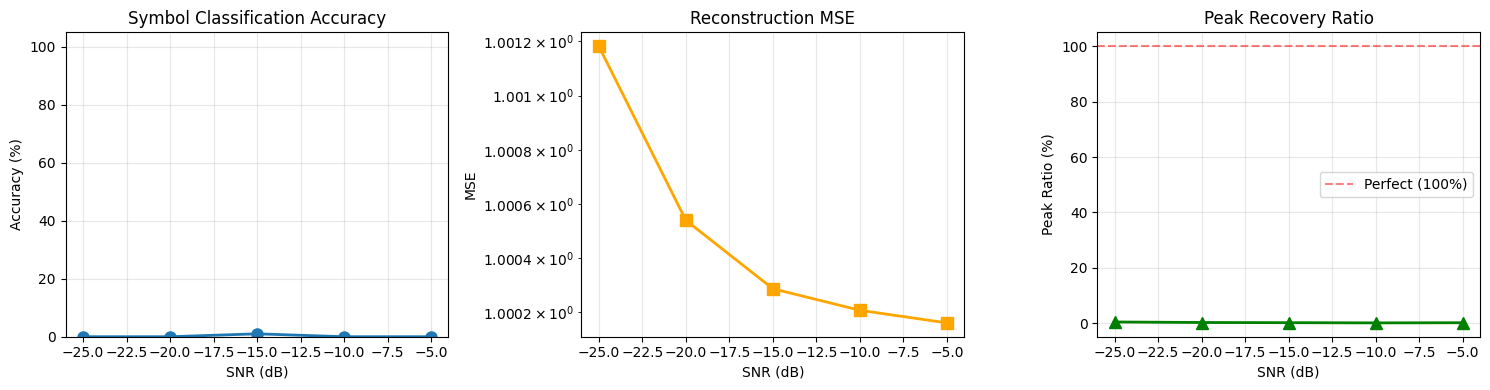


✅ Quantitative evaluation complete!


In [12]:
########################################
##  8. 정량적 성능 평가 (다중 샘플)  ##
########################################

print("\n" + "="*70)
print("📊 QUANTITATIVE PERFORMANCE EVALUATION")
print("="*70)

# 테스트 파라미터
NUM_TEST_SAMPLES = 100  # 테스트할 샘플 수
TEST_SNR_LEVELS = [-25, -20, -15, -10, -5]  # 다양한 SNR 레벨

results = {snr: {'correct': 0, 'total': 0, 'mse': [], 'peak_ratio': []} for snr in TEST_SNR_LEVELS}

print(f"\n🧪 Testing with {NUM_TEST_SAMPLES} samples at each SNR level...")
print(f"SNR levels: {TEST_SNR_LEVELS} dB\n")

for snr in TEST_SNR_LEVELS:
    print(f"\n{'─'*70}")
    print(f"Testing SNR = {snr} dB")
    print(f"{'─'*70}")
    
    for i in range(NUM_TEST_SAMPLES):
        # 랜덤 심볼 선택
        test_sym = np.random.randint(0, 512)
        
        # 1. 클린 IQ
        clean_iq_test = X_clean_iq[test_sym]
        
        # 2. 노이즈 추가
        noisy_iq_test = lora.awgn_iq(clean_iq_test, snr)
        
        # 3. Complex 스펙트로그램 생성
        noisy_flat, noisy_params = generate_complex_spectrogram(noisy_iq_test, fs, bw)
        
        # 4. BAMv3 복원 (compress -> decompress)
        compressed = model.compress(noisy_flat.reshape(1, -1))
        restored_flat = model.decompress(compressed).flatten()
        
        # 5. 역변환
        mid = len(restored_flat) // 2
        real_restored_norm = restored_flat[:mid].reshape(noisy_params['shape'])
        imag_restored_norm = restored_flat[mid:].reshape(noisy_params['shape'])
        
        # 역정규화
        real_restored = real_restored_norm * (noisy_params['r_max'] - noisy_params['r_min']) + noisy_params['r_min']
        imag_restored = imag_restored_norm * (noisy_params['i_max'] - noisy_params['i_min']) + noisy_params['i_min']
        
        # Complex 재결합
        Zxx_restored = real_restored + 1j * imag_restored
        
        # 6. 역 STFT
        Zxx_unshifted = np.fft.ifftshift(Zxx_restored, axes=0)
        _, iq_restored = istft(
            Zxx_unshifted, 
            fs=fs, 
            window='hann',
            nperseg=128, 
            noverlap=64,
            nfft=512, 
            input_onesided=False
        )
        
        # 길이 맞추기 (Resample)
        target_len = len(clean_iq_test)
        if len(iq_restored) != target_len:
            iq_restored = resample(iq_restored, target_len)
        
        # 7. Dechirp
        try:
            code_clean, peak_clean = estimate_symbol_custom(clean_iq_test, "clean", sf, fs, bw)
            code_restored, peak_restored = estimate_symbol_custom(iq_restored, "restored", sf, fs, bw)
            
            # 정확도 체크
            if code_restored == test_sym:
                results[snr]['correct'] += 1
            results[snr]['total'] += 1
            
            # Peak ratio
            if peak_clean > 0:
                results[snr]['peak_ratio'].append(peak_restored / peak_clean)
            
            # MSE 계산
            mse = np.mean(np.abs(iq_restored - clean_iq_test)**2)
            results[snr]['mse'].append(mse)
            
        except Exception as e:
            print(f"  ⚠️ Error at sample {i}: {e}")
            results[snr]['total'] += 1
    
    # 중간 결과 출력
    acc = results[snr]['correct'] / results[snr]['total'] * 100
    avg_mse = np.mean(results[snr]['mse']) if results[snr]['mse'] else 0
    avg_peak = np.mean(results[snr]['peak_ratio']) if results[snr]['peak_ratio'] else 0
    
    print(f"  ✓ Accuracy: {results[snr]['correct']}/{results[snr]['total']} = {acc:.1f}%")
    print(f"  ✓ Avg MSE: {avg_mse:.6f}")
    print(f"  ✓ Avg Peak Ratio: {avg_peak:.2%}")

# 최종 결과 요약
print("\n" + "="*70)
print("📈 FINAL RESULTS SUMMARY")
print("="*70)

print(f"\n{'SNR (dB)':<10} {'Accuracy':<15} {'MSE':<15} {'Peak Ratio':<15}")
print("─"*70)

for snr in TEST_SNR_LEVELS:
    acc = results[snr]['correct'] / results[snr]['total'] * 100
    avg_mse = np.mean(results[snr]['mse']) if results[snr]['mse'] else 0
    avg_peak = np.mean(results[snr]['peak_ratio']) if results[snr]['peak_ratio'] else 0
    
    print(f"{snr:<10} {acc:>6.1f}%{'':<8} {avg_mse:>8.6f}{'':<6} {avg_peak:>6.1%}{'':<8}")

# 전체 평균
total_correct = sum(r['correct'] for r in results.values())
total_samples = sum(r['total'] for r in results.values())
overall_acc = total_correct / total_samples * 100

print("─"*70)
print(f"{'Overall':<10} {overall_acc:>6.1f}%")
print("="*70)

# 시각화
plt.figure(figsize=(15, 4))

# 1. Accuracy vs SNR
plt.subplot(1, 3, 1)
snrs = TEST_SNR_LEVELS
accs = [results[snr]['correct'] / results[snr]['total'] * 100 for snr in snrs]
plt.plot(snrs, accs, 'o-', linewidth=2, markersize=8)
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy (%)')
plt.title('Symbol Classification Accuracy')
plt.grid(True, alpha=0.3)
plt.ylim([0, 105])

# 2. MSE vs SNR
plt.subplot(1, 3, 2)
mses = [np.mean(results[snr]['mse']) for snr in snrs]
plt.plot(snrs, mses, 's-', linewidth=2, markersize=8, color='orange')
plt.xlabel('SNR (dB)')
plt.ylabel('MSE')
plt.title('Reconstruction MSE')
plt.grid(True, alpha=0.3)
plt.yscale('log')

# 3. Peak Ratio vs SNR
plt.subplot(1, 3, 3)
peaks = [np.mean(results[snr]['peak_ratio']) * 100 for snr in snrs]
plt.plot(snrs, peaks, '^-', linewidth=2, markersize=8, color='green')
plt.xlabel('SNR (dB)')
plt.ylabel('Peak Ratio (%)')
plt.title('Peak Recovery Ratio')
plt.grid(True, alpha=0.3)
plt.axhline(y=100, color='r', linestyle='--', alpha=0.5, label='Perfect (100%)')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\n✅ Quantitative evaluation complete!")
